In [1]:
!pip install yfinance pandas matplotlib
!apt-get install -y fonts-nanum > /dev/null 2>&1
!fc-cache -fv > /dev/null 2>&1

In [2]:
# ── 한글 폰트 설정 ──
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Nanum 폰트 경로 찾기
nanum_fonts = [f for f in fm.findSystemFonts() if 'Nanum' in f or 'nanum' in f]
if nanum_fonts:
    fm.fontManager.addfont(nanum_fonts[0])
    prop = fm.FontProperties(fname=nanum_fonts[0])
    matplotlib.rcParams['font.family'] = prop.get_name()
else:
    matplotlib.rcParams['font.family'] = 'NanumGothic'

matplotlib.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지
print(f"✅ 폰트 설정 완료: {matplotlib.rcParams['font.family']}")

✅ 폰트 설정 완료: ['NanumSquareRound']


In [24]:
# ==========================
# ⚙️ 설정값 (여기만 수정)
# ==========================
TICKERS       = ['TQQQ', 'SOXL', 'TECL']  # ✅ 종목 추가/제거 자유롭게
START_DATE    = '2025-01-01'   # 시작일 (YYYY-MM-DD)
INITIAL_KRW   = 10_000_000     # 총 투자 원금 (원) - 종목 수만큼 균등 배분
USD_KRW       = 1450           # 적용 환율 (원/달러)
TARGET_PROFIT = 0.05          # 목표 수익률 (0.02 = +2%)
DIVIDE        = 40             # 분할 횟수

In [25]:
import yfinance as yf
import pandas as pd
import matplotlib.ticker as mticker

# ── 데이터 다운로드 ──
price_dict = {}
for ticker in TICKERS:
    df = yf.download(ticker, start=START_DATE, auto_adjust=True, progress=False)[['Close']].dropna()
    df.index = pd.to_datetime(df.index)
    price_dict[ticker] = df['Close'].squeeze()

spy_df = yf.download('SPY', start=START_DATE, auto_adjust=True, progress=False)[['Close']].dropna()
spy_df.index = pd.to_datetime(spy_df.index)
spy_series = spy_df['Close'].squeeze()

# 공통 날짜
common_dates = price_dict[TICKERS[0]].index
for ticker in TICKERS[1:]:
    common_dates = common_dates.intersection(price_dict[ticker].index)
common_dates = common_dates.intersection(spy_series.index)

prices_df  = pd.DataFrame(
    {ticker: price_dict[ticker].loc[common_dates].values.astype(float) for ticker in TICKERS},
    index=common_dates
)
spy_prices = spy_series.loc[common_dates].values.astype(float)
dates      = common_dates

# ── 계좌 초기화 ──
initial_usd = INITIAL_KRW / USD_KRW
alloc_usd   = initial_usd / len(TICKERS)

accounts = {}
for ticker in TICKERS:
    accounts[ticker] = {
        'cash': alloc_usd, 'holdings': 0.0, 'avg': 0.0,
        'day': 0, 'daily_invest': alloc_usd / DIVIDE,
        'profit': 0.0, 'sell_count': 0,
    }

asset_history = []
sell_events   = []

# ── 백테스트 루프 ──
for i, date in enumerate(dates):
    day_total = 0.0
    for ticker in TICKERS:
        acc   = accounts[ticker]
        price = float(prices_df[ticker].iloc[i])

        if acc['day'] < DIVIDE and acc['cash'] >= acc['daily_invest']:
            buy_qty          = acc['daily_invest'] / price
            prev             = acc['holdings']
            acc['holdings'] += buy_qty
            acc['cash']     -= acc['daily_invest']
            acc['avg']       = (acc['avg'] * prev + price * buy_qty) / acc['holdings']
            acc['day']      += 1

        if acc['holdings'] > 0 and acc['avg'] > 0:
            if (price - acc['avg']) / acc['avg'] >= TARGET_PROFIT:
                sell_val          = acc['holdings'] * price
                profit            = sell_val - acc['holdings'] * acc['avg']
                acc['profit']    += profit
                acc['cash']      += sell_val
                acc['sell_count'] += 1
                sell_events.append({'date': date, 'ticker': ticker, 'profit_krw': profit * USD_KRW})
                acc['holdings']     = 0.0
                acc['avg']          = 0.0
                acc['day']          = 0
                acc['daily_invest'] = acc['cash'] / DIVIDE

        day_total += acc['cash'] + acc['holdings'] * price

    asset_history.append({'date': date, 'total_krw': day_total * USD_KRW})

result_df  = pd.DataFrame(asset_history).set_index('date')
sell_df    = pd.DataFrame(sell_events) if sell_events else pd.DataFrame()

# ── 수익률 계산 ──
portfolio_ret = (result_df['total_krw'] / INITIAL_KRW - 1) * 100
spy_ret       = (spy_prices / spy_prices[0] - 1) * 100
ticker_ret    = {t: (prices_df[t].values / prices_df[t].values[0] - 1) * 100 for t in TICKERS}

# ── 결과 출력 ──
final_total   = float(result_df['total_krw'].iloc[-1])
total_return  = (final_total - INITIAL_KRW) / INITIAL_KRW * 100
alloc_krw     = INITIAL_KRW // len(TICKERS)
spy_total_ret = float(spy_ret[-1])

print('=' * 58)
print('📊 멀티 ETF 동시 무한매수법 백테스트 결과')
print('=' * 58)
print(f"📅 기간              : {START_DATE} ~ {dates[-1].strftime('%Y-%m-%d')}")
print(f"💰 총 투자 원금      : {INITIAL_KRW:>15,.0f} 원")
for ticker in TICKERS:
    print(f"   └ {ticker:<6} 배분   : {alloc_krw:>15,.0f} 원")
print(f"💵 환율 적용         : {USD_KRW} 원/달러")
print(f"🎯 목표 수익률       : {TARGET_PROFIT*100:.1f}%")
print(f"📦 분할 횟수         : {DIVIDE}등분")
print('-' * 58)
print(f"📈 최종 총 자산      : {final_total:>15,.0f} 원")
print(f"📊 포트폴리오 수익률 : {total_return:>+.2f}%")
print(f"📊 S&P500 수익률     : {spy_total_ret:>+.2f}% (Buy&Hold)")
print('-' * 58)
total_sells = 0
for ticker in TICKERS:
    acc        = accounts[ticker]
    profit_krw = float(acc['profit']) * USD_KRW
    unrealized = float(acc['holdings']) * float(prices_df[ticker].iloc[-1]) * USD_KRW
    sc         = acc['sell_count']
    bh_ret     = float(ticker_ret[ticker][-1])
    total_sells += sc
    print(f"📌 {ticker:<6} 실현수익 : {profit_krw:>12,.0f} 원  ({sc}회 익절) | B&H: {bh_ret:>+.1f}%")
    print(f"        미실현     : {unrealized:>12,.0f} 원")
print('-' * 58)
print(f"🔄 총 익절 횟수      : {total_sells} 회")
print('=' * 58)

📊 멀티 ETF 동시 무한매수법 백테스트 결과
📅 기간              : 2025-01-01 ~ 2026-03-10
💰 총 투자 원금      :      10,000,000 원
   └ TQQQ   배분   :       3,333,333 원
   └ SOXL   배분   :       3,333,333 원
   └ TECL   배분   :       3,333,333 원
💵 환율 적용         : 1450 원/달러
🎯 목표 수익률       : 5.0%
📦 분할 횟수         : 40등분
----------------------------------------------------------
📈 최종 총 자산      :      14,858,548 원
📊 포트폴리오 수익률 : +48.59%
📊 S&P500 수익률     : +17.19% (Buy&Hold)
----------------------------------------------------------
📌 TQQQ   실현수익 :    1,235,798 원  (11회 익절) | B&H: +26.7%
        미실현     :    3,149,907 원
📌 SOXL   실현수익 :    2,249,789 원  (25회 익절) | B&H: +98.6%
        미실현     :    1,217,249 원
📌 TECL   실현수익 :    1,593,650 원  (14회 익절) | B&H: +21.5%
        미실현     :    3,438,812 원
----------------------------------------------------------
🔄 총 익절 횟수      : 50 회


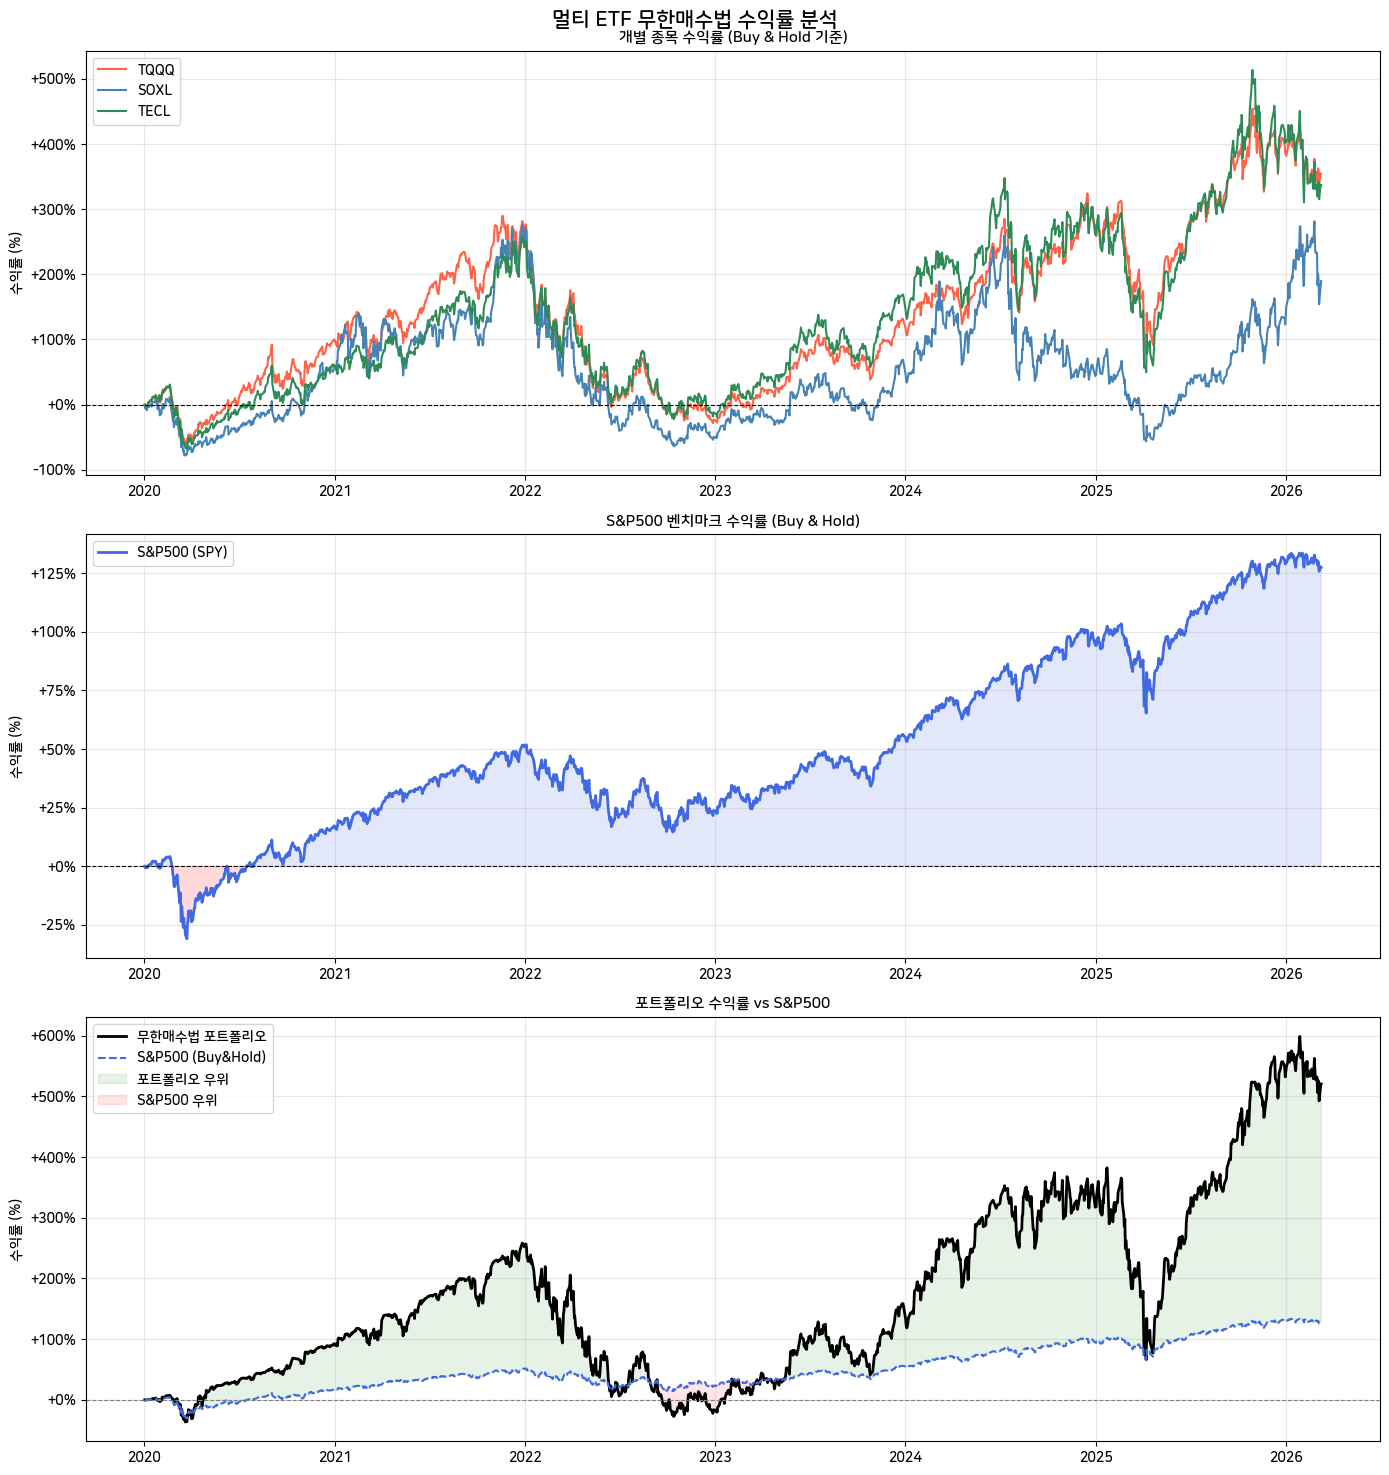

In [11]:
# ── 📊 차트 1: 수익률 비교 ──
colors = ['tomato', 'steelblue', 'seagreen', 'darkorange', 'purple', 'goldenrod', 'crimson', 'teal']

fig, axes = plt.subplots(3, 1, figsize=(14, 15))
fig.suptitle('멀티 ETF 무한매수법 수익률 분석', fontsize=15, fontweight='bold')

# 1) 개별 종목 수익률 (Buy & Hold)
ax1 = axes[0]
for idx, ticker in enumerate(TICKERS):
    ax1.plot(dates, ticker_ret[ticker], color=colors[idx % len(colors)], linewidth=1.5, label=ticker)
ax1.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax1.set_title('개별 종목 수익률 (Buy & Hold 기준)', fontsize=11)
ax1.set_ylabel('수익률 (%)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:+.0f}%'))
ax1.legend()
ax1.grid(alpha=0.3)

# 2) S&P500 수익률
ax2 = axes[1]
ax2.plot(dates, spy_ret, color='royalblue', linewidth=2.0, label='S&P500 (SPY)')
ax2.fill_between(dates, 0, spy_ret, where=(spy_ret >= 0), alpha=0.15, color='royalblue')
ax2.fill_between(dates, 0, spy_ret, where=(spy_ret <  0), alpha=0.15, color='red')
ax2.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax2.set_title('S&P500 벤치마크 수익률 (Buy & Hold)', fontsize=11)
ax2.set_ylabel('수익률 (%)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:+.0f}%'))
ax2.legend()
ax2.grid(alpha=0.3)

# 3) 포트폴리오 vs S&P500
ax3 = axes[2]
ax3.plot(dates, portfolio_ret.values, color='black',     linewidth=2.0, label='무한매수법 포트폴리오')
ax3.plot(dates, spy_ret,             color='royalblue', linewidth=1.5, label='S&P500 (Buy&Hold)', linestyle='--')
ax3.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
ax3.fill_between(dates, portfolio_ret.values, spy_ret,
    where=(portfolio_ret.values >= spy_ret), alpha=0.1, color='green', label='포트폴리오 우위')
ax3.fill_between(dates, portfolio_ret.values, spy_ret,
    where=(portfolio_ret.values <  spy_ret), alpha=0.1, color='red',   label='S&P500 우위')
ax3.set_title('포트폴리오 수익률 vs S&P500', fontsize=11)
ax3.set_ylabel('수익률 (%)')
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:+.0f}%'))
ax3.legend()
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()

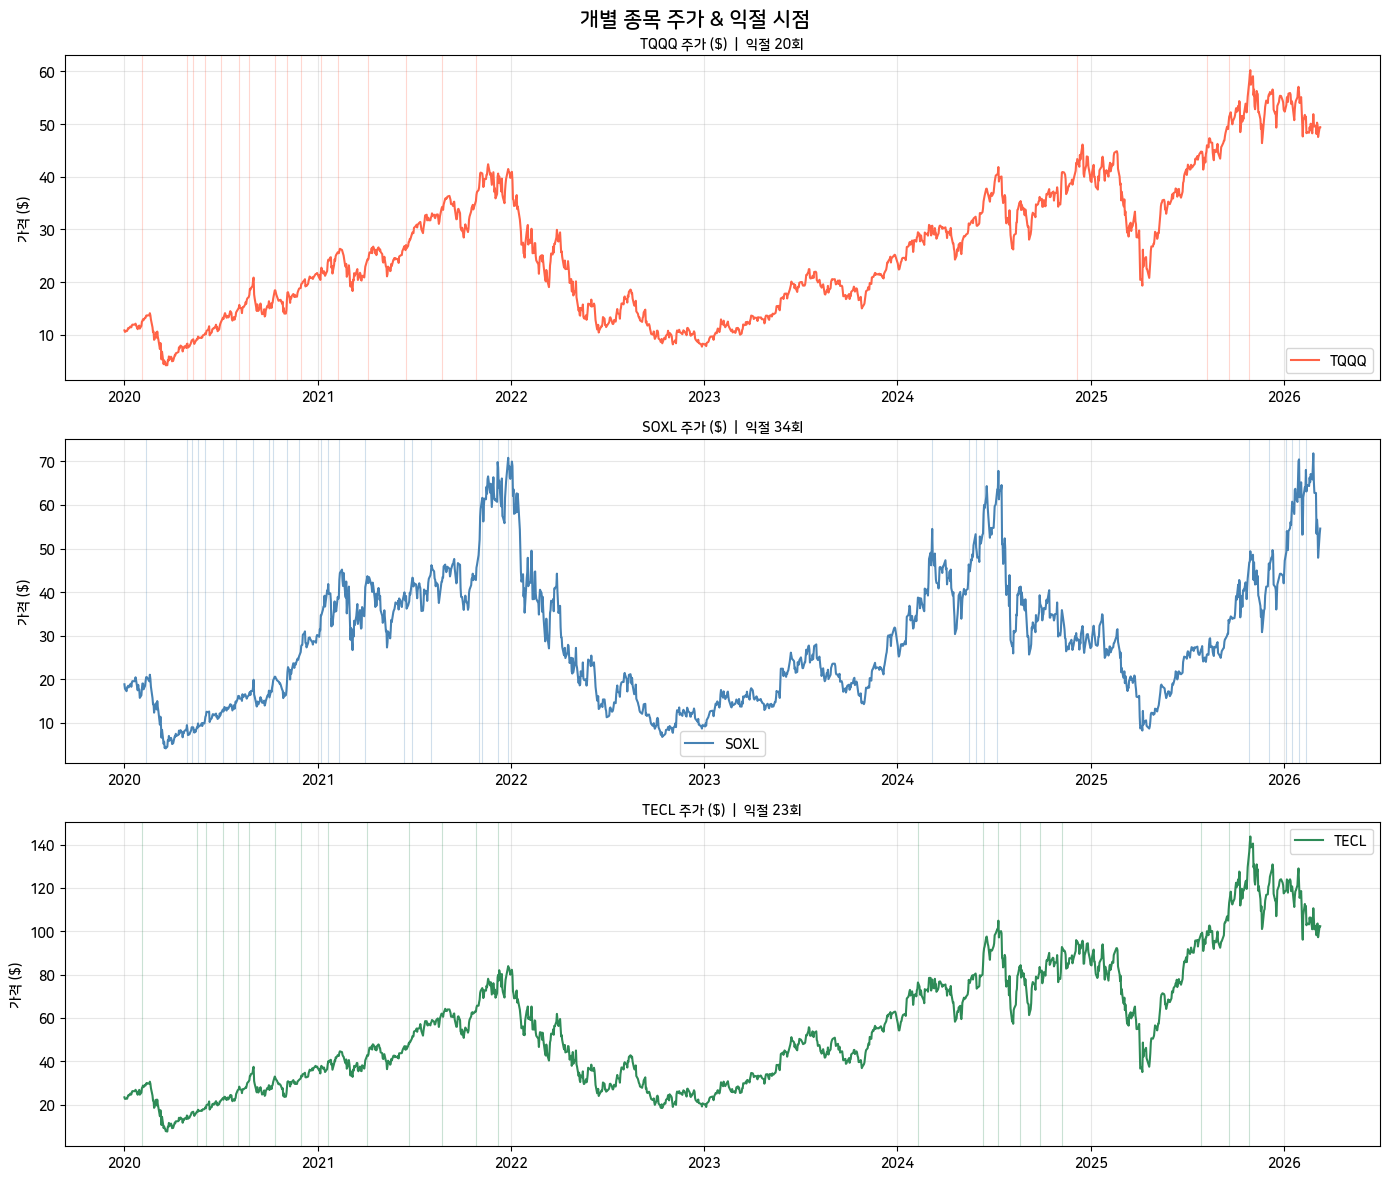

In [12]:
# ── 📊 차트 2: 개별 종목 주가 & 익절 시점 ──
sell_date_map = {ticker: [] for ticker in TICKERS}
for e in sell_events:
    sell_date_map[e['ticker']].append(e['date'])

n = len(TICKERS)
fig, axes = plt.subplots(n, 1, figsize=(14, 4 * n))
if n == 1:
    axes = [axes]
fig.suptitle('개별 종목 주가 & 익절 시점', fontsize=15, fontweight='bold')

for idx, ticker in enumerate(TICKERS):
    ax    = axes[idx]
    color = colors[idx % len(colors)]
    ax.plot(prices_df.index, prices_df[ticker], color=color, linewidth=1.5, label=ticker)
    for sd in sell_date_map[ticker]:
        ax.axvline(x=sd, color=color, alpha=0.25, linewidth=0.8)
    sc = accounts[ticker]['sell_count']
    ax.set_title(f'{ticker} 주가 ($)  |  익절 {sc}회', fontsize=10)
    ax.set_ylabel('가격 ($)')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
# ── 매도 이력 테이블 ──
if len(sell_df) > 0:
    sell_df2 = sell_df.copy()
    sell_df2['date'] = pd.to_datetime(sell_df2['date']).dt.strftime('%Y-%m-%d')
    sell_df2['profit_krw'] = sell_df2['profit_krw'].apply(lambda x: f'{float(x):,.0f}')
    sell_df2.columns = ['날짜', '종목', '실현수익(원)']
    print(sell_df2.to_string(index=False))
else:
    print("매도 이력 없음")

        날짜   종목   실현수익(원)
2020-02-04 TECL   199,205
2020-02-05 TQQQ   200,073
2020-02-12 SOXL   262,126
2020-04-29 SOXL   644,367
2020-04-30 TQQQ   348,641
2020-05-08 SOXL    94,685
2020-05-11 TQQQ    68,060
2020-05-18 TECL   358,833
2020-05-20 SOXL   131,631
2020-06-02 TQQQ   149,033
2020-06-03 SOXL   162,594
2020-06-05 TECL   144,478
2020-07-02 TQQQ   258,742
2020-07-06 SOXL   287,842
2020-07-06 TECL   258,039
2020-07-30 SOXL   223,226
2020-08-03 TECL   323,018
2020-08-05 TQQQ   260,267
2020-08-24 TECL   197,659
2020-08-25 TQQQ   186,180
2020-09-01 SOXL   376,370
2020-10-01 SOXL   378,371
2020-10-09 SOXL    99,754
2020-10-12 TQQQ   620,917
2020-10-12 TECL   640,457
2020-11-05 TQQQ   278,476
2020-11-05 SOXL   480,471
2020-11-27 SOXL   251,029
2020-11-30 TECL   485,357
2020-12-01 TQQQ   271,733
2021-01-07 SOXL   859,769
2021-01-08 TQQQ   395,990
2021-01-21 SOXL   178,069
2021-01-21 TECL   647,919
2021-02-08 TQQQ   330,493
2021-02-11 SOXL   469,917
2021-04-01 SOXL 1,098,486
2021-04-05 T